# Emulating and calibrating a nuclear breakup reaction

This notebook is a complete Bayesian calibration of an expensive model for nuclear breakup reactions using BAND framework tools [`bfrescox`](https://github.com/bandframework/Bfrescox) and [`surmise`](https://github.com/bandframework/surmise). The goal is to reproduce the [**Sürer, Nunes, Plumlee & Wild, *Phys. Rev. C* 106, 024607 (2022)**.](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.106.024607).

---

### The physics

$^{8}$B is a *proton halo* nucleus: a single proton bound to a $^{7}$Be core by only
137 keV, so loosely that it orbits far outside the core. Fire it at a $^{208}$Pb target at
80 MeV/nucleon and it breaks apart:

$$^{8}\mathrm{B} + {}^{208}\mathrm{Pb} \;\longrightarrow\; {}^{7}\mathrm{Be} + p + {}^{208}\mathrm{Pb}$$

We model this with **continuum discretized coupled channels** (CDCC) in
[FRESCOX](https://github.com/LLNL/Frescox). This a very computationall expensive simulation. We drive `FRESCOX` using
[bfrescoxpro](https://bfrescox.readthedocs.io/en/latest/advanced_users.html). The goal is learn from data -- in particular, the breakup cross section $d\sigma_{bu}/(d\Omega dE)$, the four uncertain parameters of the 
$^{7}$Be–$p$ effective interaction:

| | meaning | range | truth |
|---|---|---|---|
| $R_C$ | Coulomb radius | [2, 3] fm | 2.391 |
| $R_{\rm WS}$ | Woods-Saxon radius | [2, 3] fm | 2.391 |
| $a_{\rm WS}$ | Woods-Saxon diffuseness | [0.4, 0.9] fm | 0.52 |
| $V_{so}$ | spin-orbit depth | [2, 8] MeV | 4.898 |

For any given point in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space, the depth 
of the central well of the $^{7}$Be–$p$ effective interaction, $V$, is rescaled by `FRESCOX`, so the proton separation energy stays at its 
measured 137 keV.

### Why do we need `surmise`?

One CDCC evaluation costs about **65 core-hours**. MCMC needs at least $10^5$ of them, which is not
possible. `surmise` is a toolkit for building fast ***emulators*** of expensive reduced order models, 
and then performing model ***calibration*** using the emulator, rather than the expensive model. This
is done by training a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) on the mapping 
from parameter space to the observable output. This learned mapping is then used to sample new points in 
parameter space to compare to observed data during model calibration.


For this work, a 500-point design (samples in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space) was  
computed once (~32,500 core-hours on an HPC cluster). In this notebook we will use`surmise` to fit a GP-based emulator to those outputs, and then perform a Bayesian model calibration to infer a posterior distribution $p(R_C, R_{\rm WS}, a_{\rm WS}, V_{so} | \boldsymbol{y}_\text{obs})$. `data/training.npz` contains the results of the training campaign; `model/run_design_point.py` is a script that allows it to be reproduced (if you have the time and cores to burn!).

### Why mock data

The original paper, and this example, are demonstrations of the validity of the emulation $\rightarrow$ calibration process applied to breakup reactions. Therefore, we generate synthetic "true" data for fixed $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-values, and then generate training data by sampling in  $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space. The goal is to see if we can then infer the correct true values by calibrating the (emulator of) the breakup model to our synthetic data. This tells about the validity of trying to infer these parameters from real experimental data, and about how the (computationally necessary) introduction of an emulator might affect this inference. 

> **Runtime** ~5 minutes

## 1. Setup

In [1]:
%matplotlib inline
import warnings

import corner
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sps
from surmise.calibration import calibrator
from surmise.emulation import emulator

warnings.filterwarnings("ignore")  # surmise is chatty about its GP fits
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "legend.frameon": False}
)
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8880"

# surmise 0.4.0 draws a random subsample of the design when it fits GP
# hyperparameters, using global numpy state.  Seeding makes this notebook
# reproducible; without it the numbers move slightly on every re-run.
SEED = 0
np.random.seed(SEED)

PARAMS = ("R_C", "R_WS", "a_WS", "V_so")
LABELS = (r"$R_C$ [fm]", r"$R_{\rm WS}$ [fm]", r"$a_{\rm WS}$ [fm]", r"$V_{so}$ [MeV]")
RANGES = np.array([[2.0, 3.0], [2.0, 3.0], [0.4, 0.9], [2.0, 8.0]])
LO, SPAN = RANGES[:, 0], RANGES[:, 1] - RANGES[:, 0]
print("ready")

ready


## 2. The data

Rather than emulating and calibrating the entire 2D, energy and angle dependent breakup cross section $d\sigma_{bu}/(d\Omega dE)$, we instead integrate respectively over $E$ and $\theta$ to isolate the angle and energy dependence in two different observables: 
- $d\sigma_{bu}/d\Omega$ 
- $d\sigma_{bu}/dE$.

These are what would actually be measured in an experiment (breakup measurements are typically low statistics, so energy-angle correlations are not typically accessible).

 - `training.npz` holds $\boldsymbol{f}$, all the training data (many points in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space)
 - `mock_data.npz` holds, $\boldsymbol{y}_\text{obs}$, the synthetic observations at the one true $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$,

both for both of these two observables. 

In [2]:
d = np.load("data/training.npz")
mock = np.load("data/mock_data.npz")

theta, f, x = d["theta"], d["f"], d["x"]
y, yvar = mock["y"], mock["yvar"]
angles, energies = mock["angles_deg"], mock["energies_mev"]
truth_out, TRUTH = mock["truth_output"], mock["theta_truth"]
ANG, ENE = x[:, 0] == 0, x[:, 0] == 1

print(f"theta  {theta.shape}   (samples x parameters)")
print(f"f      {f.shape}   (observables x samples)   <- note the orientation")
print(f"x      {x.shape}   (observables x [kind, coordinate])")
print()
print(
    f"observables: {ANG.sum()} angular (b/sr) + {ENE.sum()} energy (mb/MeV) = {len(x)}"
)
print(f"  angles   {angles.min():.2f} to {angles.max():.2f} deg")
print(f"  energies {energies.min():.3f} to {energies.max():.3f} MeV")
print()
print("truth:", {n: float(v) for n, v in zip(PARAMS, TRUTH)})

theta  (500, 4)   (samples x parameters)
f      (45, 500)   (observables x samples)   <- note the orientation
x      (45, 2)   (observables x [kind, coordinate])

observables: 25 angular (b/sr) + 20 energy (mb/MeV) = 45
  angles   0.00 to 3.00 deg
  energies 0.075 to 2.925 MeV

truth: {'R_C': 2.391, 'R_WS': 2.391, 'a_WS': 0.52, 'V_so': 4.898}


## 3. What the simulator produces

Each design point yields two cross sections: a breakup **angular** distribution
$d\sigma/d\Omega$ and a breakup **energy** distribution $d\sigma/dE$. Plotting all 500
shows how strongly the four parameters move the observables — and that the spread is very
asymmetric, with a long tail toward large cross sections.

Some parameter combinations put a resonance in the $^{7}$Be–$p$ system and $d\sigma/dE$
blows up by more than an order of magnitude. Following the paper, training runs with a peak above
1000 mb/MeV are discarded: such outputs have essentially zero posterior density and only
make the emulator's job harder.

kept 399 of 500 runs (20.2% cut; the paper cuts 21.4%)


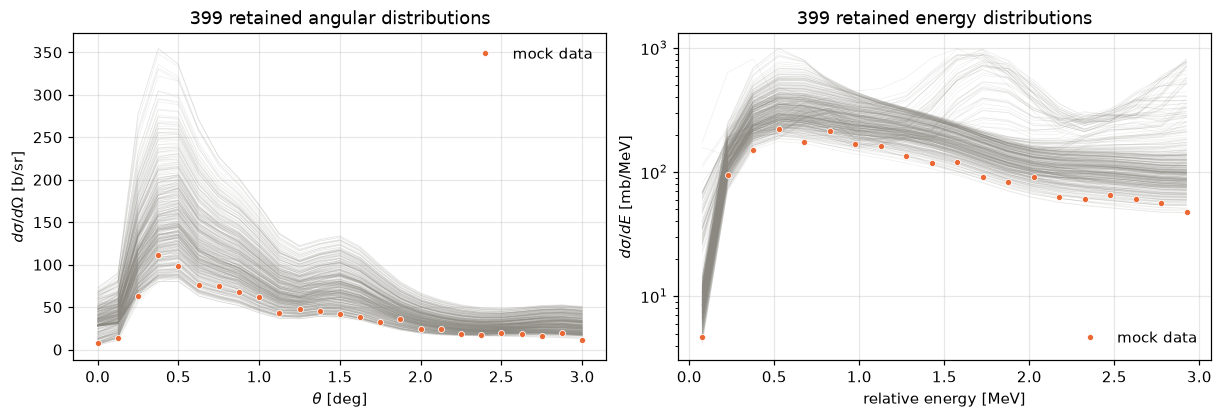

at the truth parameters: dsigma/dOmega peaks at 99.9 b/sr, dsigma/dE at 208.9 mb/MeV
the paper's Fig. 7 shows ~100 b/sr and ~210 mb/MeV


In [3]:
keep = ~np.isnan(f).any(axis=0) & (np.nanmax(f[ENE], axis=0) <= 1000.0)
print(
    f"kept {keep.sum()} of {len(keep)} runs "
    f"({100 * (~keep).mean():.1f}% cut; the paper cuts 21.4%)"
)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
for a, m, xs, xl, yl, ttl in (
    (ax[0], ANG, angles, r"$\theta$ [deg]", r"$d\sigma/d\Omega$ [b/sr]", "angular"),
    (ax[1], ENE, energies, "relative energy [MeV]", r"$d\sigma/dE$ [mb/MeV]", "energy"),
):
    a.plot(xs, f[np.ix_(m, keep)], color=GREY, lw=0.4, alpha=0.15)
    a.plot(
        xs,
        y[m],
        "o",
        ms=4,
        color=ORANGE,
        mec="white",
        mew=0.5,
        ls="none",
        label="mock data",
        zorder=5,
    )
    a.set(xlabel=xl, ylabel=yl, title=f"{int(keep.sum())} retained {ttl} distributions")
    a.legend()
ax[1].set_yscale("log")
plt.show()

print(
    f"at the truth parameters: dsigma/dOmega peaks at "
    f"{truth_out[ANG].max():.1f} b/sr, dsigma/dE at {truth_out[ENE].max():.1f} mb/MeV"
)
print("the paper's Fig. 7 shows ~100 b/sr and ~210 mb/MeV")

## 4. Fitting the emulator

`PCGPwM` standardizes each observable, reduces the output with PCA, and fits an
independent GP to each principal component — the construction in the paper's Appendix B. 

We fit it to $\log\sigma$ rather than $\sigma$ because cross sections are strictly positive.

In [4]:
theta_k, f_k = theta[keep], f[:, keep]

rng = np.random.default_rng(SEED)
order = rng.permutation(len(theta_k))
n_test = int(round(0.25 * len(theta_k)))
test, train = np.sort(order[:n_test]), np.sort(order[n_test:])
print(f"train {len(train)}, test {len(test)}")


def fit(rows):
    """Fit PCGPwM to log(sigma) on the training split."""
    np.random.seed(SEED)  # surmise subsamples internally
    return emulator(
        x=x[rows],
        theta=theta_k[train],
        f=np.log(f_k[rows][:, train]),
        method="PCGPwM",
        args={"warnings": False},
    )


def predict(emu, rows, th):
    """Predictive mean, back in linear units (b/sr, mb/MeV)."""
    return np.exp(emu.predict(x=x[rows], theta=np.atleast_2d(th)).mean())


ALL = np.ones(len(x), bool)
emus = {"angular": fit(ANG), "energy": fit(ENE), "combined": fit(ALL)}
print("fitted:", ", ".join(emus))

train 299, test 100
fitted: angular, energy, combined


## 5. Validating the emulator

We use the following metrics:

- **Held-out accuracy** — predict the 25% of design points the GP never saw
- **Accuracy at the truth** — the single point the calibration actually has to get right.
  
A held-out score averages over the design and can look healthy while the emulator is 
poor exactly where the answer lives, so it is worth checking accuracy-at-truth separately (although this is only possible in a mock data experiment like this).

In [5]:
def r2_of(emu, rows):
    pred, true = predict(emu, rows, theta_k[test]), f_k[rows][:, test]
    return 1 - np.sum((pred - true) ** 2) / np.sum(
        (true - true.mean(1, keepdims=True)) ** 2
    )


print(
    f"{'observable':>10} {'d':>4} {'test r2':>9} {'median |rel err|':>17} "
    f"{'at truth':>10} {'negative':>9}"
)
for name, rows in (("angular", ANG), ("energy", ENE), ("combined", ALL)):
    emu = emus[name]
    pred, true = predict(emu, rows, theta_k[test]), f_k[rows][:, test]
    at_truth = predict(emu, rows, TRUTH).ravel()
    tv = truth_out[rows]
    print(
        f"{name:>10} {int(rows.sum()):4d} {r2_of(emu, rows):9.4f} "
        f"{np.median(np.abs(pred - true) / true):17.4f} "
        f"{np.median(np.abs(at_truth - tv) / tv):10.4f} "
        f"{int((at_truth < 0).sum()):9d}"
    )

observable    d   test r2  median |rel err|   at truth  negative
   angular   25    0.9942            0.0067     0.1276         0
    energy   20    0.9340            0.0152     0.2540         0
  combined   45    0.9432            0.0125     0.1600         0


The diagnostics the paper plots (its Figs. 4, 11, 12): **standardized errors** should
look like a standard normal if the predictive variance is honest, and **relative errors**
should sit tightly around zero.

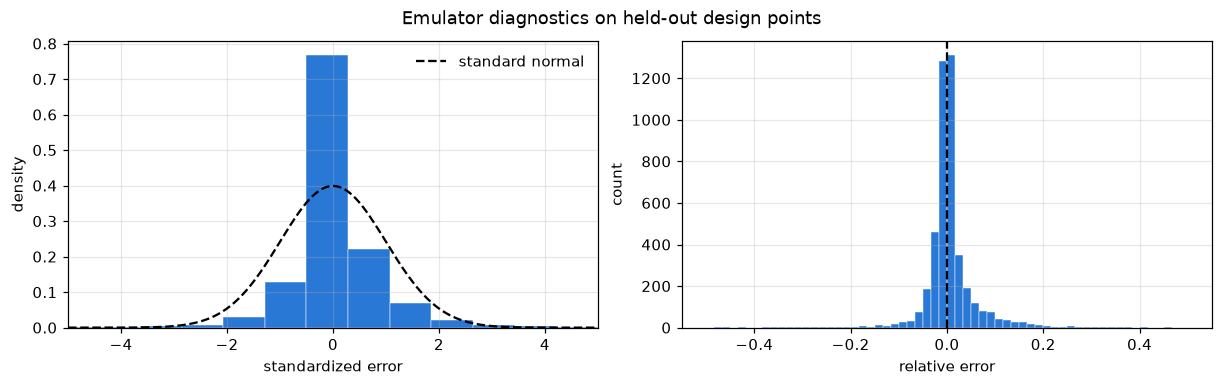

In [6]:
emu = emus["combined"]
p = emu.predict(x=x, theta=theta_k[test])
mean_lin = np.exp(p.mean())
var_lin = mean_lin**2 * p.var()  # delta method, log -> linear
true = f_k[:, test]
std_err = ((mean_lin - true) / np.sqrt(var_lin)).ravel()
rel_err = ((mean_lin - true) / true).ravel()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
ax[0].hist(std_err, bins=60, density=True, color=BLUE, edgecolor="white", lw=0.3)
g = np.linspace(-5, 5, 300)
ax[0].plot(
    g,
    np.exp(-(g**2) / 2) / np.sqrt(2 * np.pi),
    color="black",
    lw=1.5,
    ls="--",
    label="standard normal",
)
ax[0].set(xlabel="standardized error", ylabel="density", xlim=(-5, 5))
ax[0].legend()
ax[1].hist(rel_err, bins=60, color=BLUE, edgecolor="white", lw=0.3, range=(-0.5, 0.5))
ax[1].axvline(0, color="black", lw=1.5, ls="--")
ax[1].set(xlabel="relative error", ylabel="count")
fig.suptitle("Emulator diagnostics on held-out design points")
plt.show()

## 6. Calibration

Our emulator is satisfacorally fit. Now the Bayesian step. The prior is Beta(3.5, 3.5) rescaled onto each parameter range —
concentrated toward the middle, vanishing at the edges — and the posterior is sampled with parallel-tempered Langevin Monte Carlo (`PTLMC`).

Because the emulator lives in log space, the observations are transformed to match: a 10%
relative error is a constant additive 0.1 in log units.

In [7]:
class Prior:
    """Beta(3.5, 3.5) on each parameter, rescaled to its range."""

    def lpdf(t):  # noqa: N805 - surmise calls it unbound
        t = np.atleast_2d(t)
        total = sum(
            sps.beta.logpdf((t[:, i] - LO[i]) / SPAN[i], 3.5, 3.5) - np.log(SPAN[i])
            for i in range(4)
        )
        return total.reshape(len(t), 1)  # the (n, 1) shape is required

    def rnd(n):  # noqa: N805
        return sps.beta.rvs(3.5, 3.5, size=(n, 4)) * SPAN + LO


np.random.seed(SEED)

In [8]:
%%time
REL_ERR = 0.35  # maximum relative error at truth of GP + 10% experimental err
cal = calibrator(
    emu=emus["combined"],
    y=np.log(y),  # emulator is in log space
    x=x,
    thetaprior=Prior,
    method="directbayeswoodbury",
    yvar=np.full(y.size, REL_ERR**2),  # additive in log
    args={"sampler": "PTLMC", "maxtemp": 30},
)

CPU times: user 45min 57s, sys: 1.38 s, total: 45min 58s
Wall time: 8min 36s


In [9]:
draws = cal.theta.rnd(5000)
print(f"posterior draws: {draws.shape}")

posterior draws: (5000, 4)


In [10]:
print(
    f"  {'param':6s} {'mean':>8} {'sd':>8} {'2.5%':>8} {'97.5%':>8} {'truth':>8}"
    f" {'sd/prior':>9}  covers truth?"
)
for i, name in enumerate(PARAMS):
    c = draws[:, i]
    lo, hi = np.percentile(c, [2.5, 97.5])
    print(
        f"  {name:6s} {c.mean():8.4f} {c.std():8.4f} {lo:8.4f} {hi:8.4f} "
        f"{TRUTH[i]:8.4f} {c.std() / SPAN[i]:9.3f}  "
        f"{'yes' if lo <= TRUTH[i] <= hi else 'NO'}"
    )
print(
    "\nBeta(3.5, 3.5) has sd/range = 0.177, so smaller means the data were informative"
)

  param      mean       sd     2.5%    97.5%    truth  sd/prior  covers truth?
  R_C      2.4282   0.1560   2.1524   2.7635   2.3910     0.156  yes
  R_WS     2.3933   0.0477   2.3126   2.4624   2.3910     0.048  yes
  a_WS     0.5210   0.0430   0.4438   0.6227   0.5200     0.086  yes
  V_so     5.2226   1.1239   3.0900   7.2312   4.8980     0.187  yes

Beta(3.5, 3.5) has sd/range = 0.177, so smaller means the data were informative


## 7. The posterior

The corner plot shows every 1-D marginal and every 2-D projection at once — the paper's
Figs. 5 and 6 combined. Blue lines mark the truth.

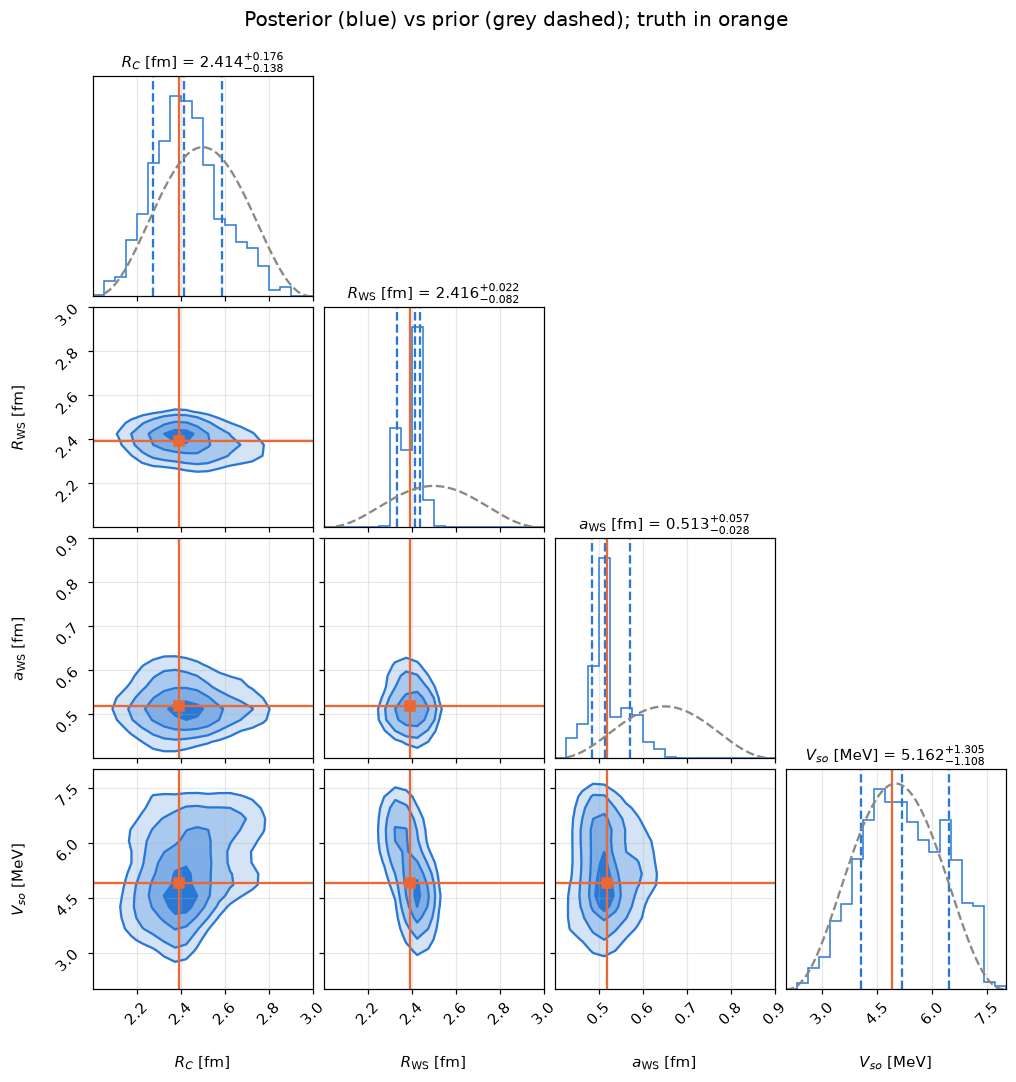

In [11]:
fig = corner.corner(
    draws,
    labels=list(LABELS),
    truths=list(TRUTH),
    truth_color=ORANGE,
    color=BLUE,
    range=[tuple(r) for r in RANGES],  # show the full prior support
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 10},
    hist_kwargs={"density": True},
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
)
# overlay the prior on each diagonal, so "informative" is visible rather than asserted
prior_draws = Prior.rnd(20000)
axes = np.array(fig.axes).reshape(4, 4)
for i in range(4):
    ax = axes[i, i]
    grid = np.linspace(*RANGES[i], 200)
    dens = sps.beta.pdf((grid - LO[i]) / SPAN[i], 3.5, 3.5) / SPAN[i]
    ax.plot(grid, dens, color=GREY, lw=1.5, ls="--")
fig.suptitle(
    "Posterior (blue) vs prior (grey dashed); truth in orange", y=1.02, fontsize=13
)
plt.show()

The headline result: **$R_{\rm WS}$ and $a_{\rm WS}$ are
sharply determined by breakup data, while $R_C$ and $V_{so}$ are barely informed at all** —
their marginals sit almost on top of the prior. 

## 8. Posterior predictive

Pushing the posterior back through the emulator gives credible intervals on the
observables themselves — the paper's Fig. 7. This closes the loop: a calibrated model
should reproduce the data it was fitted to, with intervals that are neither too narrow nor
too wide.

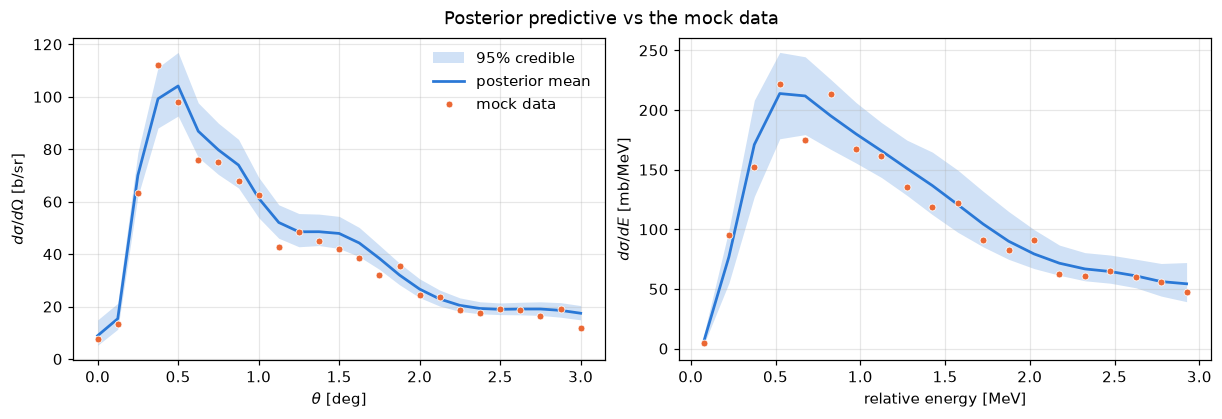

In [12]:
pred_obj = cal.predict(x)
pred_log = pred_obj.rnd(s=2000)  # needed before empirical_coverage()
pred = np.exp(pred_log)  # back to b/sr and mb/MeV

lo, hi = np.percentile(pred, [2.5, 97.5], axis=0)
mu = pred.mean(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
for a, m, xs, xl, yl in (
    (ax[0], ANG, angles, r"$\theta$ [deg]", r"$d\sigma/d\Omega$ [b/sr]"),
    (ax[1], ENE, energies, "relative energy [MeV]", r"$d\sigma/dE$ [mb/MeV]"),
):
    a.fill_between(xs, lo[m], hi[m], color=BLUE, alpha=0.22, lw=0, label="95% credible")
    a.plot(xs, mu[m], color=BLUE, lw=1.8, label="posterior mean")
    a.plot(
        xs,
        y[m],
        "o",
        ms=4.5,
        color=ORANGE,
        mec="white",
        mew=0.5,
        ls="none",
        label="mock data",
    )
    a.set(xlabel=xl, ylabel=yl)
ax[0].legend()
fig.suptitle("Posterior predictive vs the mock data")
plt.show()

## 9. Empirical coverage

If the posterior uncertainty is honest, a nominal $p$% interval
should contain the observation about $p$% of the time.

There are **two different intervals**:

- a **credible interval for the model prediction** — where the calibrated simulator says
  the true cross section lies;
- a **predictive interval for a new observation** — the same, *plus* the 10% measurement
  noise the data carry.

The band plotted above is the first. The data should not fall inside it $p$% of the time,
because the data are noisy and that band does not know it. Below we compute both.

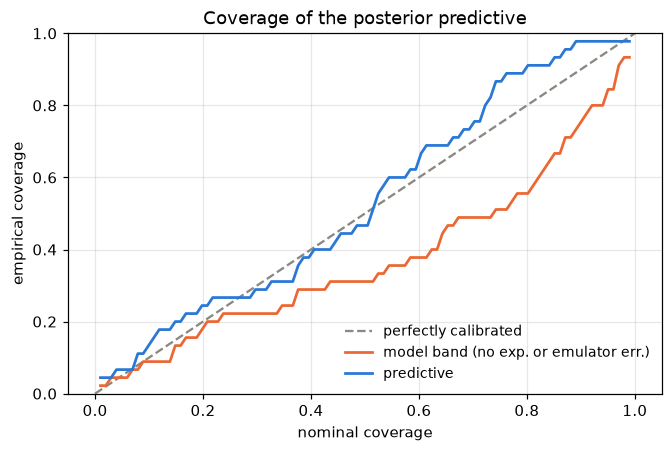

In [15]:
levels = np.linspace(0.01, 0.99, 100)

pred_obj.empirical_coverage(levels)
_, cov_model = pred_obj.info["coverage"]
cov_model = np.atleast_1d(cov_model)

# Add the measurement noise to get a predictive interval for a new observation.
# A 10% relative error is additive N(0, 0.1^2) in log space.
noise = np.random.default_rng(1).normal(0.0, 0.10, size=pred_log.shape)
pred_obs = np.exp(pred_log + noise)


def coverage(sample):
    return np.array(
        [
            (
                (y >= np.percentile(sample, 100 * (1 - L) / 2, axis=0))
                & (y <= np.percentile(sample, 100 * (1 + L) / 2, axis=0))
            ).mean()
            for L in levels
        ]
    )


cov_obs = coverage(pred_obs)
fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)
ax.plot([0.0, 1], [0.0, 1], color=GREY, ls="--", lw=1.5, label="perfectly calibrated")
ax.plot(
    levels,
    cov_model,
    color=ORANGE,
    ms=8,
    lw=1.8,
    label="model band (no exp. or emulator err.)",
)
ax.plot(levels, cov_obs, color=BLUE, ms=8, lw=1.8, label="predictive")
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    title="Coverage of the posterior predictive",
)
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim([0, 1])
plt.show()

Once the measurement and emulator noise is included, coverage is close to nominal.

## 10. Summary
### What we have done

We took samples of observables for a complicated breakup calculation $^{8}\mathrm{B} + {}^{208}\mathrm{Pb} \;\longrightarrow\; {}^{7}\mathrm{Be} + p + {}^{208}\mathrm{Pb}$ calculated using `Bfrescox`, at 500 different values of $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$, and trained a Gaussian process emulator using `surmise` to learn the mapping from parameter samples to breakup cross sections. We then used that trained emulator to do a Bayesian calibration of $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$ to mock data - which we also generated using `Bfrescox`, with some ground truth in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space. Using the emulator, we were able to do a full Bayesian calibration, effectively recovering the truth, in under a minute. This problem would be intractable if we were forced to use the full CDCC calculation!

### Regenerating the training data

`data/training.npz` came from 500 CDCC runs at ~65 core-hours each. To reproduce it:

```bash
pip install -r requirements.txt -r requirements-model.txt   # needs a Fortran compiler + MPI
python model/run_design_point.py --index 0 --ranks 32       # one point, ~2 h on 32 ranks
python model/run_design_point.py --assemble                 # samples/ -> data/training.npz
```

In practice this is a SLURM array over `--index 0..499`. See `model/run_design_point.py`
and the `README.md`. If you have an idle cluster, feel free to try to regenerate the training data, or, better yet, adapt this example to your own interesting breakup problem!